In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")

In [4]:
from pathlib import Path

BASE = Path.cwd()

df_masters = pd.read_csv(BASE / "mastersportal-programs.csv")
df_linkedin = pd.read_csv(BASE / "linkedin-data-job-titles-and-postings.csv")
df_salary = pd.read_excel(BASE / "occupation_salary.xlsx")
df_automation = pd.read_csv(BASE / "automation_data_by_state.csv", encoding="cp1252")

print("Masters:", df_masters.shape)
print("LinkedIn:", df_linkedin.shape)
print("Salary:", df_salary.shape)
print("Automation:", df_automation.shape)

Masters: (60425, 23)
LinkedIn: (14409, 2)
Salary: (1394, 20)
Automation: (702, 54)


In [5]:
print("MASTERS columns:\n", df_masters.columns.tolist())
print("\nLINKEDIN columns:\n", df_linkedin.columns.tolist())
print("\nSALARY columns:\n", df_salary.columns.tolist())
print("\nAUTOMATION columns:\n", df_automation.columns.tolist())

MASTERS columns:
 ['country_name', 'country_code', 'university_name', 'university_rank', 'program_name', 'program_type', 'deadline', 'duration', 'language', 'tution_1_currency', 'tution_1_money', 'tution_1_type', 'tution_2_currency', 'tution_2_money', 'tution_2_type', 'tuition_price_specification', 'start_date', 'ielts_score', 'structure', 'academic_req', 'facts', 'city', 'program_url']

LINKEDIN columns:
 ['title', 'description']

SALARY columns:
 ['OCC_CODE', 'OCC_TITLE', 'OCC_GROUP', 'TOT_EMP', 'EMP_PRSE', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY']

AUTOMATION columns:
 ['SOC', 'Occupation', 'Probability', 'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachuset

In [6]:
country_cols = [c for c in df_masters.columns if "country" in c.lower()]
print("Country-like columns:", country_cols)

c = country_cols[0]
print(df_masters[c].value_counts().head(20))

Country-like columns: ['country_name', 'country_code']
country_name
United States     24084
United Kingdom    14130
Australia          2932
Canada             2152
Netherlands        1346
France             1282
Germany            1053
Ireland             894
China               836
Sweden              806
Italy               756
Spain               724
Greece              700
Belgium             657
Hong Kong           542
Switzerland         482
New Zealand         472
Malaysia            457
Denmark             374
Norway              348
Name: count, dtype: int64


In [7]:
US_LABELS = {"United States", "United States of America", "USA", "US"}

df_masters_us = df_masters[df_masters[c].isin(US_LABELS)].copy()

print("Before:", df_masters.shape)
print("After US filter:", df_masters_us.shape)
print(df_masters_us[c].value_counts().head(10))

Before: (60425, 23)
After US filter: (24084, 23)
country_name
United States    24084
Name: count, dtype: int64


In [10]:
print("Salary SOC example:")
print(df_salary[["OCC_CODE", "OCC_TITLE"]].head())

print("\nAutomation SOC example:")
print(df_automation[["SOC", "Occupation", "Probability"]].head())

Salary SOC example:
  OCC_CODE               OCC_TITLE
0  00-0000         All Occupations
1  11-0000  Management Occupations
2  11-1000          Top Executives
3  11-1010        Chief Executives
4  11-1011        Chief Executives

Automation SOC example:
       SOC                           Occupation  Probability
0  11-1011                     Chief Executives        0.015
1  11-1021      General and Operations Managers        0.160
2  11-2011  Advertising and Promotions Managers        0.039
3  11-2021                   Marketing Managers        0.014
4  11-2022                       Sales Managers        0.013


In [11]:
df_salary["OCC_CODE"] = df_salary["OCC_CODE"].astype(str).str.strip()
df_automation["SOC"] = df_automation["SOC"].astype(str).str.strip()

# Check overlap
common_soc = set(df_salary["OCC_CODE"]).intersection(set(df_automation["SOC"]))
print("Number of overlapping SOC codes:", len(common_soc))

Number of overlapping SOC codes: 688


In [12]:
df_masters_us.columns

Index(['country_name', 'country_code', 'university_name', 'university_rank', 'program_name', 'program_type', 'deadline', 'duration', 'language', 'tution_1_currency', 'tution_1_money',
       'tution_1_type', 'tution_2_currency', 'tution_2_money', 'tution_2_type', 'tuition_price_specification', 'start_date', 'ielts_score', 'structure', 'academic_req', 'facts', 'city',
       'program_url'],
      dtype='str')

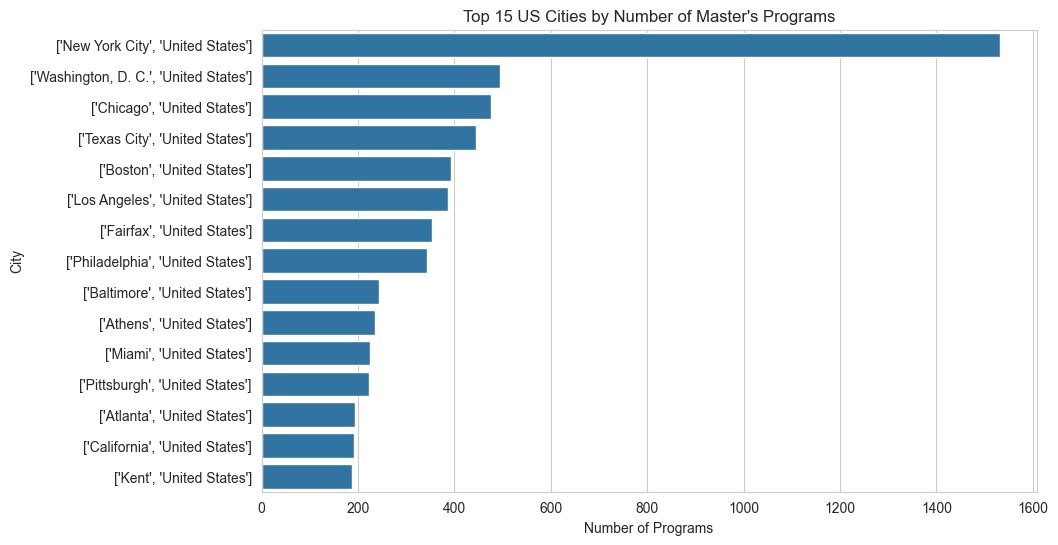

In [13]:
top_cities = (
    df_masters_us["city"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_cities.columns = ["city", "program_count"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_cities, x="program_count", y="city")
plt.title("Top 15 US Cities by Number of Master's Programs")
plt.xlabel("Number of Programs")
plt.ylabel("City")
plt.show()

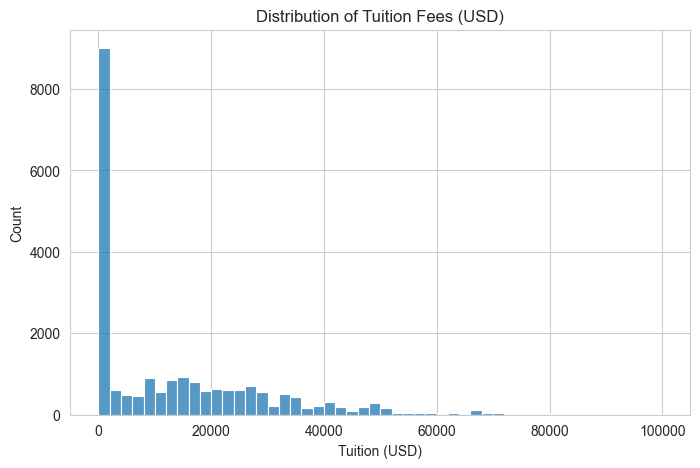

Min: 21.0
Max: 99960.0
Median: 8480.5


In [14]:
usd_tuition = df_masters_us[df_masters_us["tution_1_currency"] == "USD"]

plt.figure(figsize=(8,5))
sns.histplot(usd_tuition["tution_1_money"].dropna(), bins=50)
plt.title("Distribution of Tuition Fees (USD)")
plt.xlabel("Tuition (USD)")
plt.show()

print("Min:", usd_tuition["tution_1_money"].min())
print("Max:", usd_tuition["tution_1_money"].max())
print("Median:", usd_tuition["tution_1_money"].median())

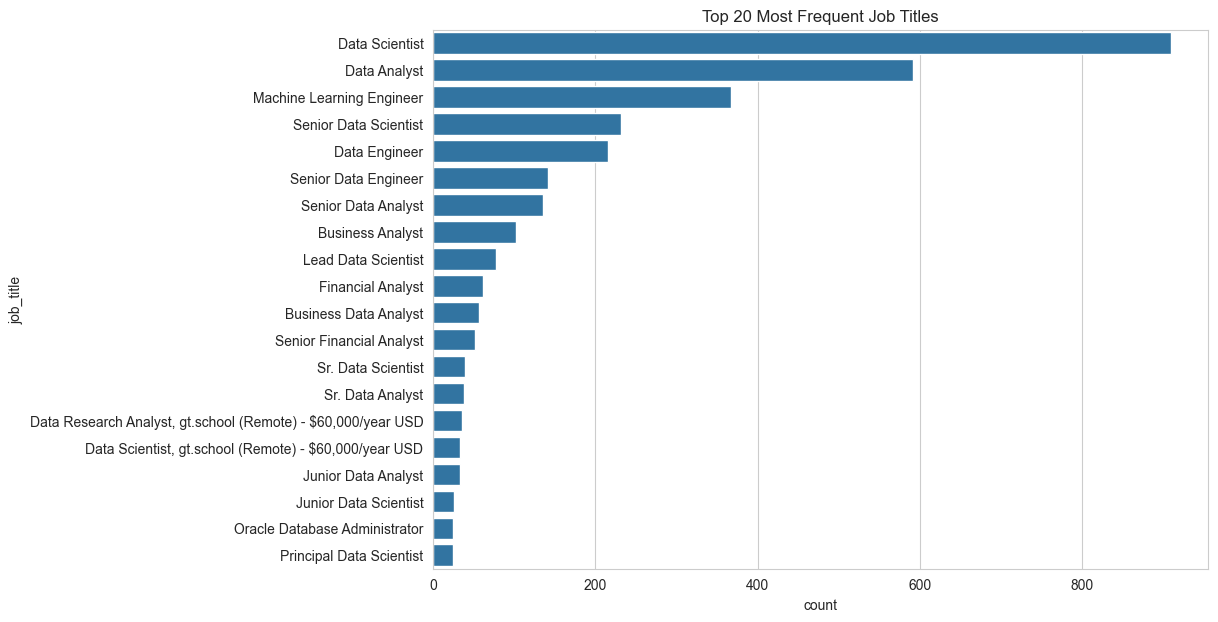

In [15]:
top_titles = (
    df_linkedin["title"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_titles.columns = ["job_title", "count"]

plt.figure(figsize=(10,7))
sns.barplot(data=top_titles, x="count", y="job_title")
plt.title("Top 20 Most Frequent Job Titles")
plt.show()

In [16]:
from collections import Counter

words = []
for t in df_linkedin["title"].astype(str):
    words += t.lower().split()

common_words = Counter(words).most_common(20)
common_words

[('data', 8240),
 ('analyst', 5667),
 ('-', 2701),
 ('scientist', 2377),
 ('engineer', 2300),
 ('senior', 2066),
 ('business', 945),
 ('learning', 882),
 ('machine', 847),
 ('research', 790),
 ('and', 574),
 ('&', 529),
 ('lead', 461),
 ('analytics', 453),
 ('sr.', 451),
 ('analyst,', 434),
 ('financial', 417),
 ('/', 383),
 ('associate', 328),
 ('manager', 321)]

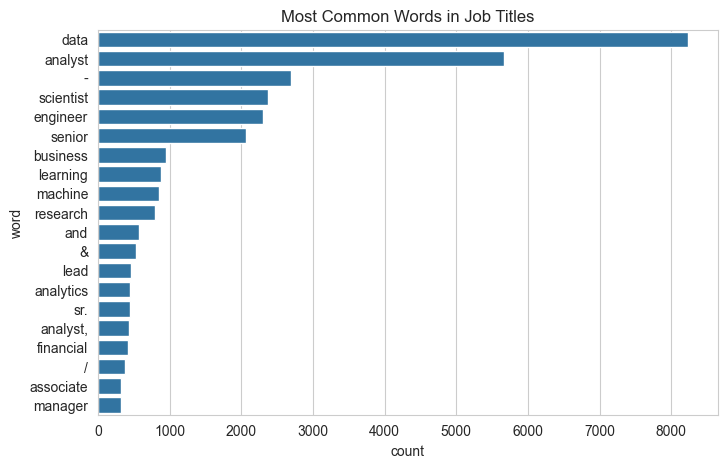

In [17]:
freq_df = pd.DataFrame(common_words, columns=["word","count"])

plt.figure(figsize=(8,5))
sns.barplot(data=freq_df, x="count", y="word")
plt.title("Most Common Words in Job Titles")
plt.show()

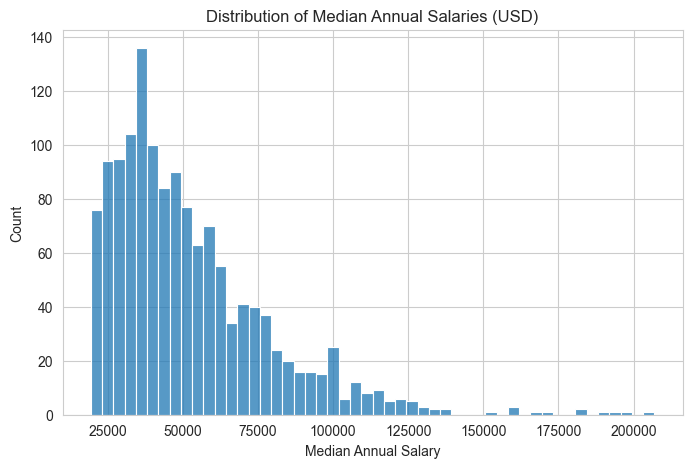

Original non-null count: 1394
Cleaned non-null count: 1382
Min median salary: 19290.0
Max median salary: 206920.0


In [20]:
# Clean A_MEDIAN: remove non-numeric characters then coerce to numeric
df_salary["A_MEDIAN_clean"] = pd.to_numeric(
    df_salary["A_MEDIAN"].astype(str).str.replace("[^0-9.-]", "", regex=True),
    errors="coerce",
)

plt.figure(figsize=(8,5))
sns.histplot(df_salary["A_MEDIAN_clean"].dropna(), bins=50)
plt.title("Distribution of Median Annual Salaries (USD)")
plt.xlabel("Median Annual Salary")
plt.show()

print("Original non-null count:", df_salary["A_MEDIAN"].notna().sum())
print("Cleaned non-null count:", df_salary["A_MEDIAN_clean"].notna().sum())
print("Min median salary:", df_salary["A_MEDIAN_clean"].min())
print("Max median salary:", df_salary["A_MEDIAN_clean"].max())

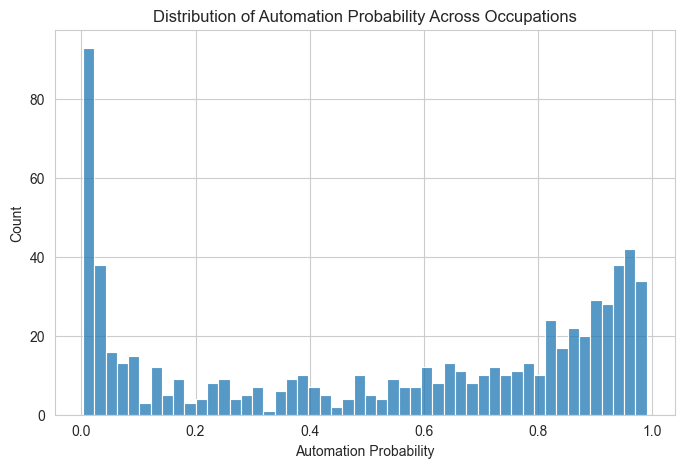

Lowest risk: 0.0028
Highest risk: 0.99


In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df_automation["Probability"], bins=50)
plt.title("Distribution of Automation Probability Across Occupations")
plt.xlabel("Automation Probability")
plt.show()

print("Lowest risk:", df_automation["Probability"].min())
print("Highest risk:", df_automation["Probability"].max())

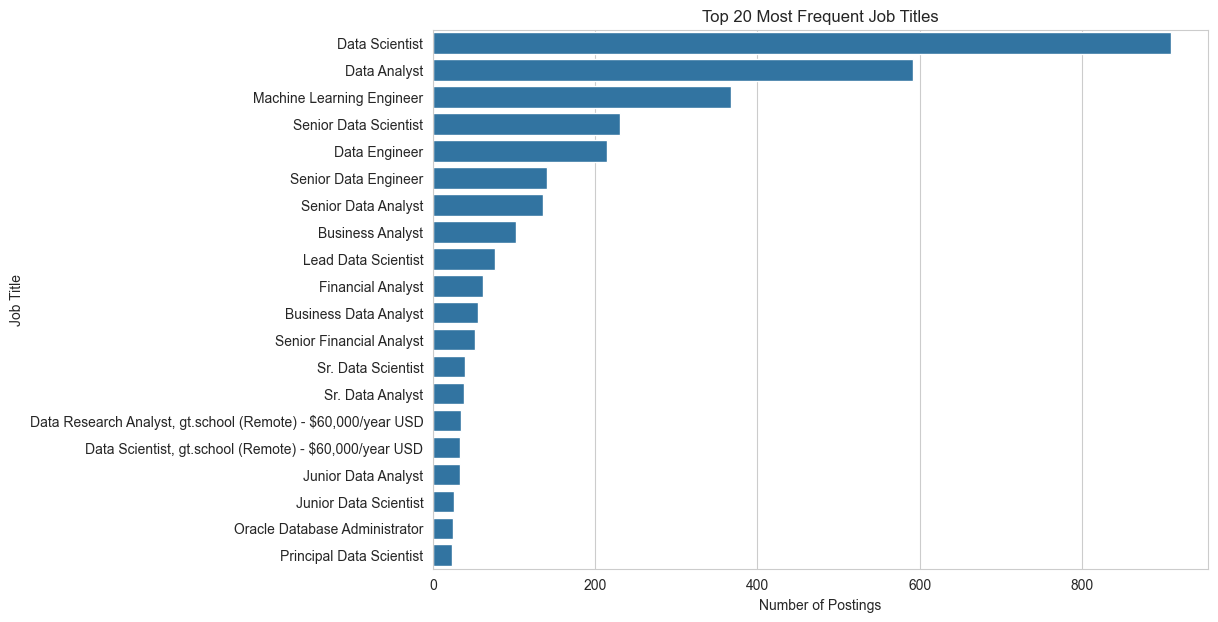

In [21]:
top_titles = (
    df_linkedin["title"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_titles.columns = ["job_title", "count"]

plt.figure(figsize=(10,7))
sns.barplot(data=top_titles, x="count", y="job_title")
plt.title("Top 20 Most Frequent Job Titles")
plt.xlabel("Number of Postings")
plt.ylabel("Job Title")
plt.show()

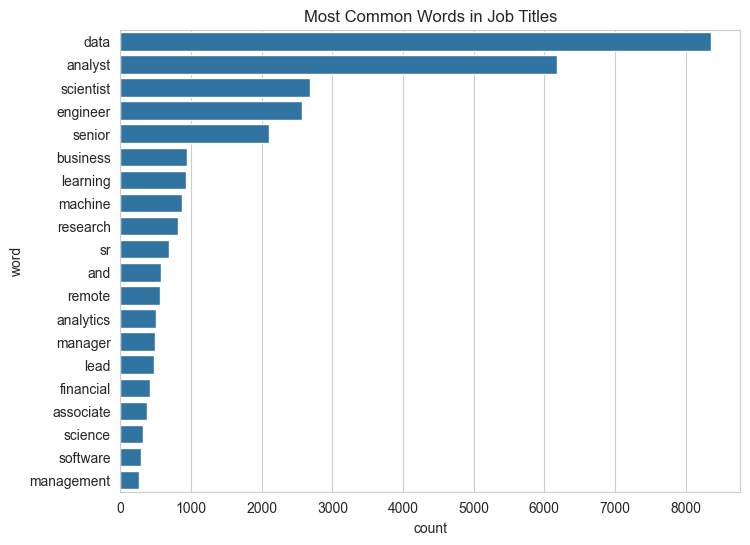

In [22]:
from collections import Counter
import re

words = []
for t in df_linkedin["title"].astype(str):
    clean = re.sub(r"[^a-zA-Z ]", "", t.lower())
    words += clean.split()

common_words = Counter(words).most_common(20)
freq_df = pd.DataFrame(common_words, columns=["word","count"])

plt.figure(figsize=(8,6))
sns.barplot(data=freq_df, x="count", y="word")
plt.title("Most Common Words in Job Titles")
plt.show()

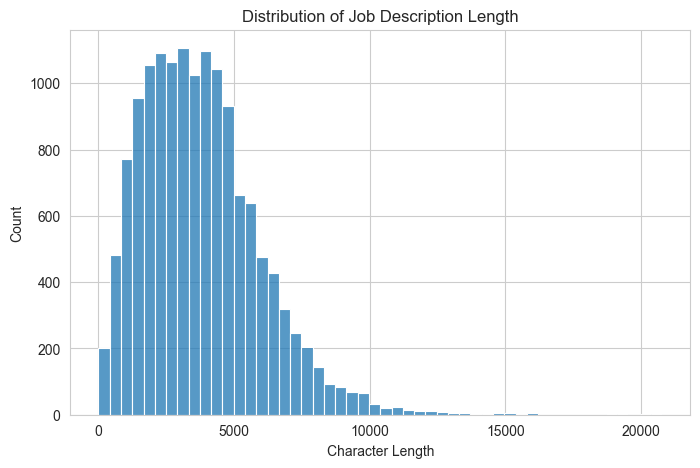

Average description length: 3783.664098827122


In [23]:
df_linkedin["desc_length"] = df_linkedin["description"].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df_linkedin["desc_length"], bins=50)
plt.title("Distribution of Job Description Length")
plt.xlabel("Character Length")
plt.show()

print("Average description length:", df_linkedin["desc_length"].mean())

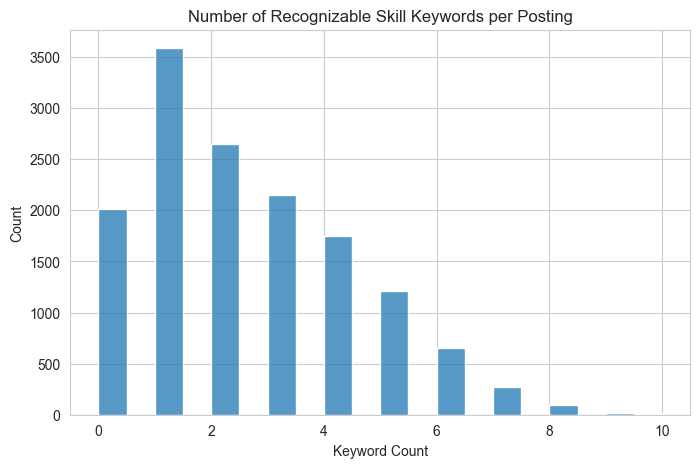

In [24]:
skill_keywords = [
    "python", "sql", "excel", "aws", "azure",
    "machine learning", "data analysis", "tableau",
    "power bi", "statistics", "pandas"
]

def count_skill(text):
    text = text.lower()
    return sum(1 for skill in skill_keywords if skill in text)

df_linkedin["skill_keyword_count"] = df_linkedin["description"].astype(str).apply(count_skill)

plt.figure(figsize=(8,5))
sns.histplot(df_linkedin["skill_keyword_count"], bins=20)
plt.title("Number of Recognizable Skill Keywords per Posting")
plt.xlabel("Keyword Count")
plt.show()

In [25]:
print("Average description length:", round(df_linkedin["desc_length"].mean(), 2))
print("Median description length:", round(df_linkedin["desc_length"].median(), 2))
print("Minimum:", df_linkedin["desc_length"].min())
print("Maximum:", df_linkedin["desc_length"].max())

Average description length: 3783.66
Median description length: 3516.0
Minimum: 16
Maximum: 20766


In [26]:
print(df_linkedin["skill_keyword_count"].value_counts().sort_index().head(10))
print("\nPostings with 3+ keywords:",
      (df_linkedin["skill_keyword_count"] >= 3).sum())

skill_keyword_count
0    2016
1    3587
2    2651
3    2153
4    1749
5    1208
6     657
7     271
8      95
9      16
Name: count, dtype: int64

Postings with 3+ keywords: 6155


In [28]:
df_linkedin["title"].value_counts().head(30)

title
Data Scientist                                                  910
Data Analyst                                                    592
Machine Learning Engineer                                       367
Senior Data Scientist                                           231
Data Engineer                                                   215
Senior Data Engineer                                            141
Senior Data Analyst                                             136
Business Analyst                                                102
Lead Data Scientist                                              77
Financial Analyst                                                62
Business Data Analyst                                            56
Senior Financial Analyst                                         52
Sr. Data Scientist                                               39
Sr. Data Analyst                                                 38
Data Research Analyst, gt.school (Remote) 

In [29]:
def map_career_bucket(title):
    t = title.lower()
    
    if "scientist" in t:
        return "Data Scientist"
    elif "machine learning" in t:
        return "ML Engineer"
    elif "engineer" in t and "data" in t:
        return "Data Engineer"
    elif "financial" in t:
        return "Financial Analyst"
    elif "analyst" in t:
        return "Data/Business Analyst"
    else:
        return "Other"

df_linkedin["career_bucket"] = df_linkedin["title"].apply(map_career_bucket)

df_linkedin["career_bucket"].value_counts()

career_bucket
Data/Business Analyst    5865
Other                    2938
Data Scientist           2744
Data Engineer            1640
ML Engineer               799
Financial Analyst         423
Name: count, dtype: int64

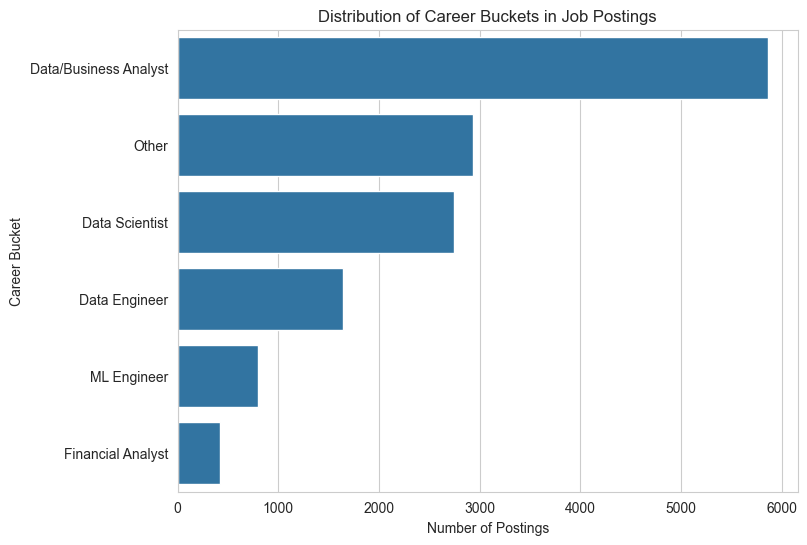

In [30]:
plt.figure(figsize=(8,6))
sns.barplot(
    x=df_linkedin["career_bucket"].value_counts().values,
    y=df_linkedin["career_bucket"].value_counts().index
)
plt.title("Distribution of Career Buckets in Job Postings")
plt.xlabel("Number of Postings")
plt.ylabel("Career Bucket")
plt.show()

In [31]:
print("Total unique job titles:", df_linkedin["title"].nunique())

# What percentage of postings are in top 20 titles?
top20_share = df_linkedin["title"].value_counts().head(20).sum() / len(df_linkedin)
print("Share of postings in top 20 titles:", round(top20_share * 100, 2), "%")

Total unique job titles: 7428
Share of postings in top 20 titles: 22.17 %


In [32]:
non_data_keywords = [
    "nurse", "teacher", "marketing", "sales", "hr",
    "human resources", "operations", "manager",
    "accountant", "consultant", "lawyer", "physician",
    "project manager", "product manager"
]

matches = []

for title in df_linkedin["title"]:
    t = title.lower()
    if any(k in t for k in non_data_keywords):
        matches.append(title)

pd.Series(matches).value_counts().head(20)

Marketing Data Analyst                                                                       18
Manager, Data Loss Prevention (DLP) Engineer (Symantec)                                      14
HRIS Analyst                                                                                  7
Marketing Analyst                                                                             7
Operations Analyst                                                                            6
Salesforce Business Analyst                                                                   6
Nurse Practitioner - NP - Clinical Research                                                   6
HR Data Analyst                                                                               5
Data Center Technical Operations Engineer I                                                   5
Registered Nurse - RN - State Psych Hospital                                                  5
Senior Data Scientist, Operations       

In [33]:
df_masters_us["city"].value_counts().head(15)

city
['New York City', 'United States']        1531
['Washington, D. C.', 'United States']     495
['Chicago', 'United States']               476
['Texas City', 'United States']            444
['Boston', 'United States']                393
['Los Angeles', 'United States']           387
['Fairfax', 'United States']               353
['Philadelphia', 'United States']          344
['Baltimore', 'United States']             244
['Athens', 'United States']                236
['Miami', 'United States']                 225
['Pittsburgh', 'United States']            222
['Atlanta', 'United States']               193
['California', 'United States']            191
['Kent', 'United States']                  188
Name: count, dtype: int64

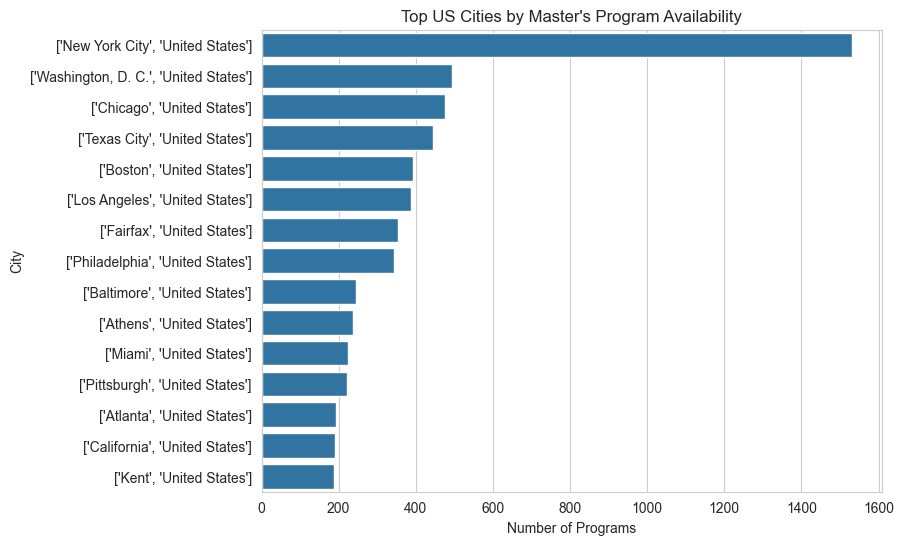

In [34]:
top_cities = df_masters_us["city"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top US Cities by Master's Program Availability")
plt.xlabel("Number of Programs")
plt.ylabel("City")
plt.show()

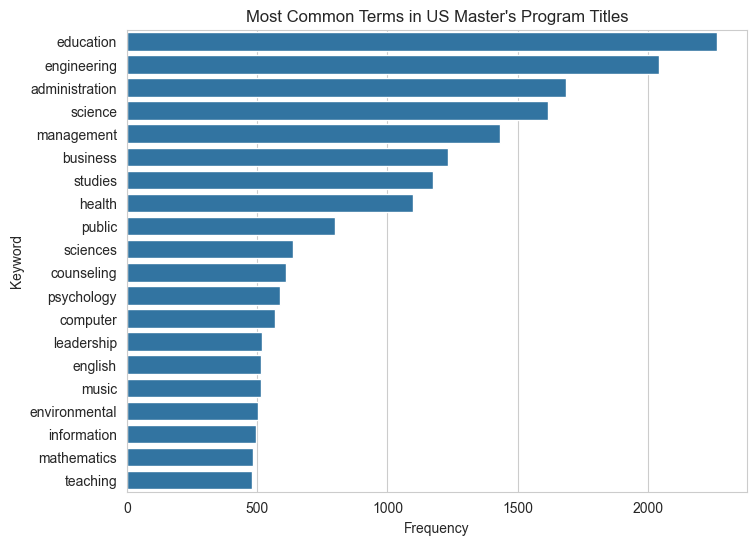

In [39]:
stop_words = {"master", "masters", "msc", "ms", "ma", "of", "in", "and", "degree"}

words = []

for name in df_masters_us["program_name"].dropna():
    tokens = name.lower().split()
    words.extend([w for w in tokens if w not in stop_words and len(w) > 3])

common_words = pd.Series(words).value_counts().head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=common_words.values, y=common_words.index)
plt.title("Most Common Terms in US Master's Program Titles")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.show()

In [40]:
df_masters_us["program_type"].value_counts()

program_type
MSc       9714
MA        5818
Master    3598
MBA       1390
MEd       1383
          ... 
MIT          1
MES          1
MMSM         1
JDMSW        1
MSAT         1
Name: count, Length: 183, dtype: int64

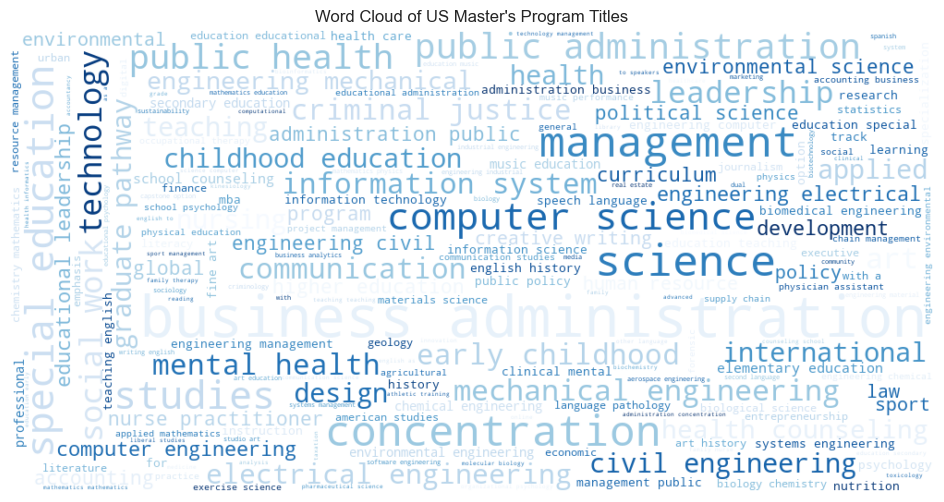

In [41]:
from wordcloud import WordCloud

text = " ".join(df_masters_us["program_name"].dropna().str.lower())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Blues",
    stopwords=stop_words
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of US Master's Program Titles")
plt.show()

In [42]:
df_masters_us["program_type"].value_counts().head(20)

program_type
MSc                         9714
MA                          5818
Master                      3598
MBA                         1390
MEd                         1383
Postgraduate Certificate     472
MEng                         282
Pre-Master                   248
MFA                          146
LLM                          128
MM                           108
MPA                           69
MAT                           63
MPH                           58
MSW                           50
Master of Music               49
Preparation Course            43
MSN                           36
MSEd                          30
Master of Fine Arts           27
Name: count, dtype: int64

In [43]:
allowed_types = ["MSc", "MBA", "MEng"]

df_masters_core = df_masters_us[
    df_masters_us["program_type"].isin(allowed_types)
].copy()

print("Core programs:", df_masters_core.shape[0])
print("Share of US programs:",
      round(df_masters_core.shape[0] / df_masters_us.shape[0] * 100, 2), "%")

Core programs: 11386
Share of US programs: 47.28 %


In [44]:
unique_programs = df_masters_core["program_name"].nunique()
print("Unique program names:", unique_programs)

Unique program names: 4535


In [45]:
df_masters_core["program_name"].value_counts().head(20)

program_name
Computer Science                     230
Chemistry                            188
Business Administration              187
Mechanical Engineering               168
Biology                              161
Master of Business Administration    154
Electrical Engineering               137
Mathematics                          135
Physics                              130
Civil Engineering                    116
Nursing                              113
Accounting                           112
Finance                              102
Chemical Engineering                  98
Biomedical Engineering                92
Statistics                            70
Engineering Management                67
Computer Engineering                  62
Geology                               56
Criminal Justice                      55
Name: count, dtype: int64

In [46]:
df_salary[["OCC_CODE", "OCC_TITLE"]].head(20)

,OCC_CODE,OCC_TITLE
0,00-0000,All Occupations
1,11-0000,Management Occupations
2,11-1000,Top Executives
3,11-1010,Chief Executives
4,11-1011,Chief Executives
5,11-1020,General and Operations Managers
6,11-1021,General and Operations Managers
7,11-1030,Legislators
8,11-1031,Legislators
9,11-2000,"Advertising, Marketing, Promotions, Public Rel..."


In [47]:
print("Total occupations in salary dataset:", df_salary.shape[0])

Total occupations in salary dataset: 1394


In [48]:
df_salary["major_group"] = df_salary["OCC_CODE"].str[:2]

df_salary["major_group"].value_counts().sort_index()

major_group
00      1
11     69
13     58
15     33
17     60
19     71
21     27
23     16
25     96
27     62
29     92
31     26
33     41
35     34
37     18
39     62
41     43
43    113
45     27
47    104
49     76
51    168
53     97
Name: count, dtype: int64

In [49]:
df_automation[["SOC", "Occupation", "Probability"]].head(20)
print("Total automation occupations:", df_automation.shape[0])

Total automation occupations: 702


In [50]:
df_automation["major_group"] = df_automation["SOC"].str[:2]
df_automation["major_group"].value_counts().sort_index()

major_group
11     31
13     30
15     15
17     34
19     42
21     13
23      8
25     22
27     36
29     44
31     14
33     19
35     16
37      8
39     30
41     20
43     52
45     11
47     56
49     50
51    103
53     48
Name: count, dtype: int64

In [51]:
# Merge salary + automation
df_occ = df_salary.merge(
    df_automation,
    left_on="OCC_CODE",
    right_on="SOC",
    how="inner"
)

print("Merged occupation count:", df_occ.shape)

Merged occupation count: (688, 77)


In [52]:
df_occ["major_group"] = df_occ["OCC_CODE"].str[:2]
df_occ["major_group"].value_counts().sort_index()

major_group
11     31
13     29
15     13
17     34
19     42
21     13
23      8
25     21
27     36
29     40
31     13
33     19
35     16
37      8
39     29
41     20
43     52
45     10
47     55
49     49
51    102
53     48
Name: count, dtype: int64

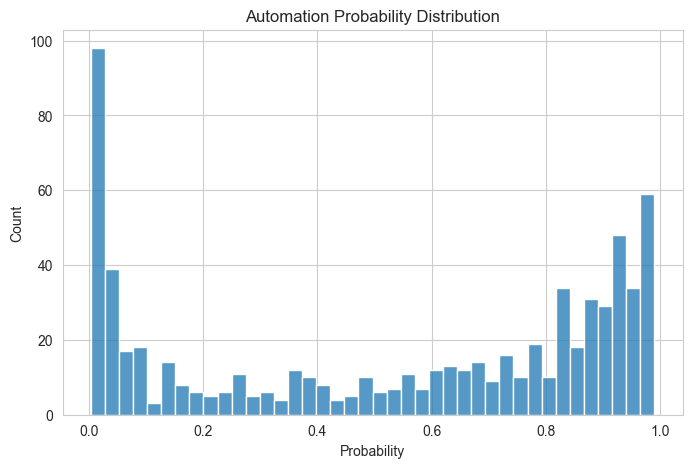

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df_occ["Probability"], bins=40)
plt.title("Automation Probability Distribution")
plt.show()

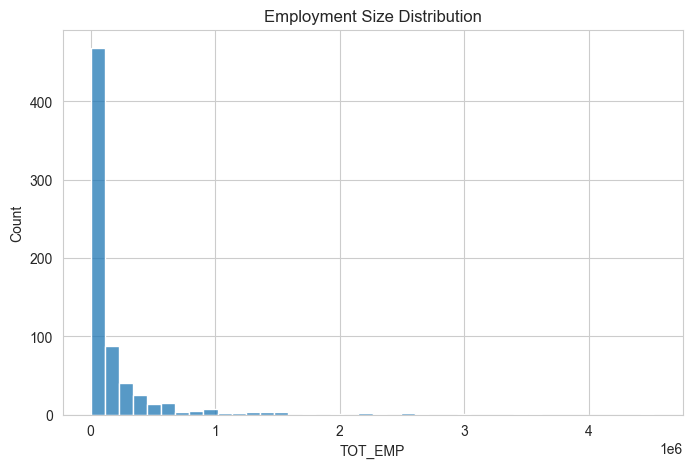

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df_occ["TOT_EMP"], bins=40)
plt.title("Employment Size Distribution")
plt.show()